# <center>🏦 Loan Approval Prediction System<center>
## <center>Third Year **DSBDA Mini Project**</center>
### <center>Team Members : Shravan Shidruk (C-29) | Divyaraj Shinde (C-30) | Tanuja Shirole (C-31) | Vrushali Shirole (C-32)</center>
### <center>Dataset: [Click Me !](https://www.kaggle.com/code/dhairyapandya1/loanapproval/input)</center>
### <center>Models: **Logistic Regression | Random Forest Classifier**</center>
---

In [108]:
## to install all libraries run :
!pip install -r requirements.txt

## Step 1: Import Libraries

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load Dataset

In [ ]:
df = pd.read_csv('loan_approval_dataset.csv')

# Strip leading/trailing whitespace from column names (dataset has spaces)
df.columns = df.columns.str.strip()

print(f"✅ Dataset loaded successfully!")
print(f"   Shape: {df.shape[0]} rows x {df.shape[1]} columns")

✅ Dataset loaded successfully!
   Shape: 4269 rows × 13 columns


In [79]:
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [80]:
df.shape

(4269, 13)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [82]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## Step 3: Data Cleaning

In [83]:
# 3.1 Check for Null Values
print("🔍 Null Value Check:")
print("─" * 40)
for col in df.columns:
    null_count = df[col].isnull().sum()
    status = '✅' if null_count == 0 else '❌'
    print(f"  {status} {col:35s}: {null_count} missing values")

print("─" * 40)
print(f"  Total missing values: {df.isnull().sum().sum()}")

🔍 Null Value Check:
────────────────────────────────────────
  ✅ loan_id                            : 0 missing values
  ✅ no_of_dependents                   : 0 missing values
  ✅ education                          : 0 missing values
  ✅ self_employed                      : 0 missing values
  ✅ income_annum                       : 0 missing values
  ✅ loan_amount                        : 0 missing values
  ✅ loan_term                          : 0 missing values
  ✅ cibil_score                        : 0 missing values
  ✅ residential_assets_value           : 0 missing values
  ✅ commercial_assets_value            : 0 missing values
  ✅ luxury_assets_value                : 0 missing values
  ✅ bank_asset_value                   : 0 missing values
  ✅ loan_status                        : 0 missing values
────────────────────────────────────────
  Total missing values: 0


In [84]:
# 3.2 Check for Duplicate Rows
duplicates = df.duplicated().sum()
print(f"🔍 Duplicate rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"   ✅ Dropped duplicates. New shape: {df.shape}")
else:
    print("   ✅ No duplicates found.")

🔍 Duplicate rows: 0
   ✅ No duplicates found.


In [85]:
# 3.3 Strip whitespace from string/object columns
# The raw CSV has leading spaces in string values like ' Graduate', ' Approved'
str_cols = df.select_dtypes(include=['object', 'string']).columns
for col in str_cols:
    df[col] = df[col].str.strip()

print("✅ Stripped whitespace from string columns.")
print("\n   education unique values  :", df['education'].unique())
print("   self_employed unique values:", df['self_employed'].unique())
print("   loan_status unique values  :", df['loan_status'].unique())

✅ Stripped whitespace from string columns.

   education unique values  : ['Graduate' 'Not Graduate']
   self_employed unique values: ['No' 'Yes']
   loan_status unique values  : ['Approved' 'Rejected']


In [86]:
# 3.4 Drop irrelevant column (loan_id is just an index)
df.drop(columns=['loan_id'], inplace=True)
print("✅ Dropped 'loan_id' column (not a feature).")
print(f"   Remaining shape: {df.shape}")

✅ Dropped 'loan_id' column (not a feature).
   Remaining shape: (4269, 12)


## Step 4: Exploratory Data Analysis (EDA)

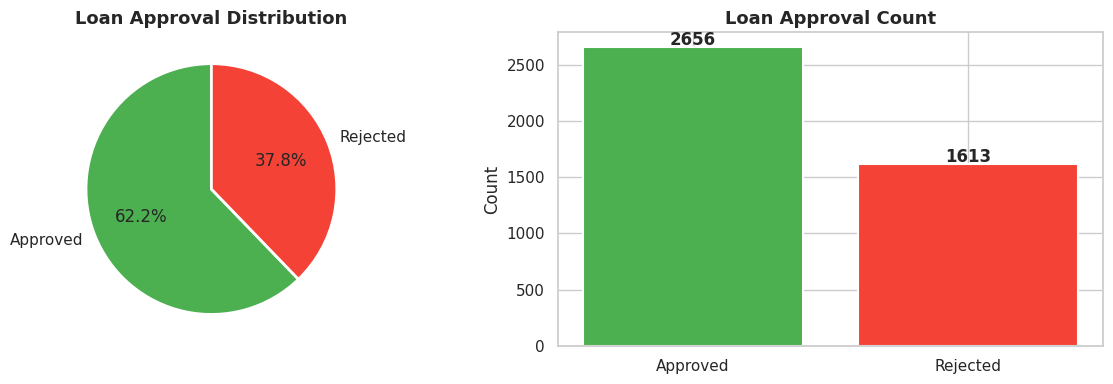

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

In [87]:
# 4.1 Class Distribution (Target Variable)
status_counts = df['loan_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie Chart
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Loan Approval Distribution', fontsize=13, fontweight='bold')

# Bar Chart
bars = axes[1].bar(status_counts.index, status_counts.values,
                   color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, status_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')
axes[1].set_title('Loan Approval Count', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
plt.savefig('eda_01_class_distribution.png', dpi=300, bbox_inches='tight', facecolor='white', format='png')
print(status_counts)

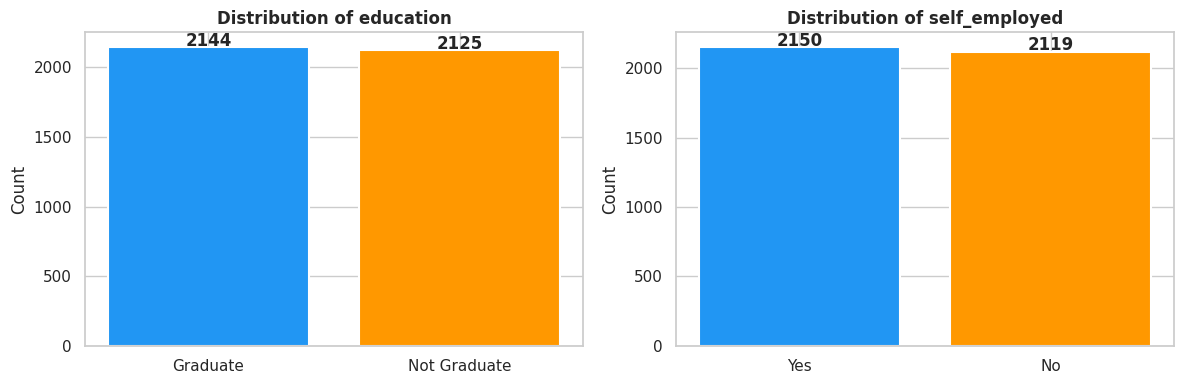

In [88]:
# 4.2 Categorical Feature Distributions
cat_cols = ['education', 'self_employed']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=['#2196F3', '#FF9800'],
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(val), ha='center', fontweight='bold')
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_02_categorical_features.png', dpi=300, bbox_inches='tight', facecolor='white', format='png')
plt.show()

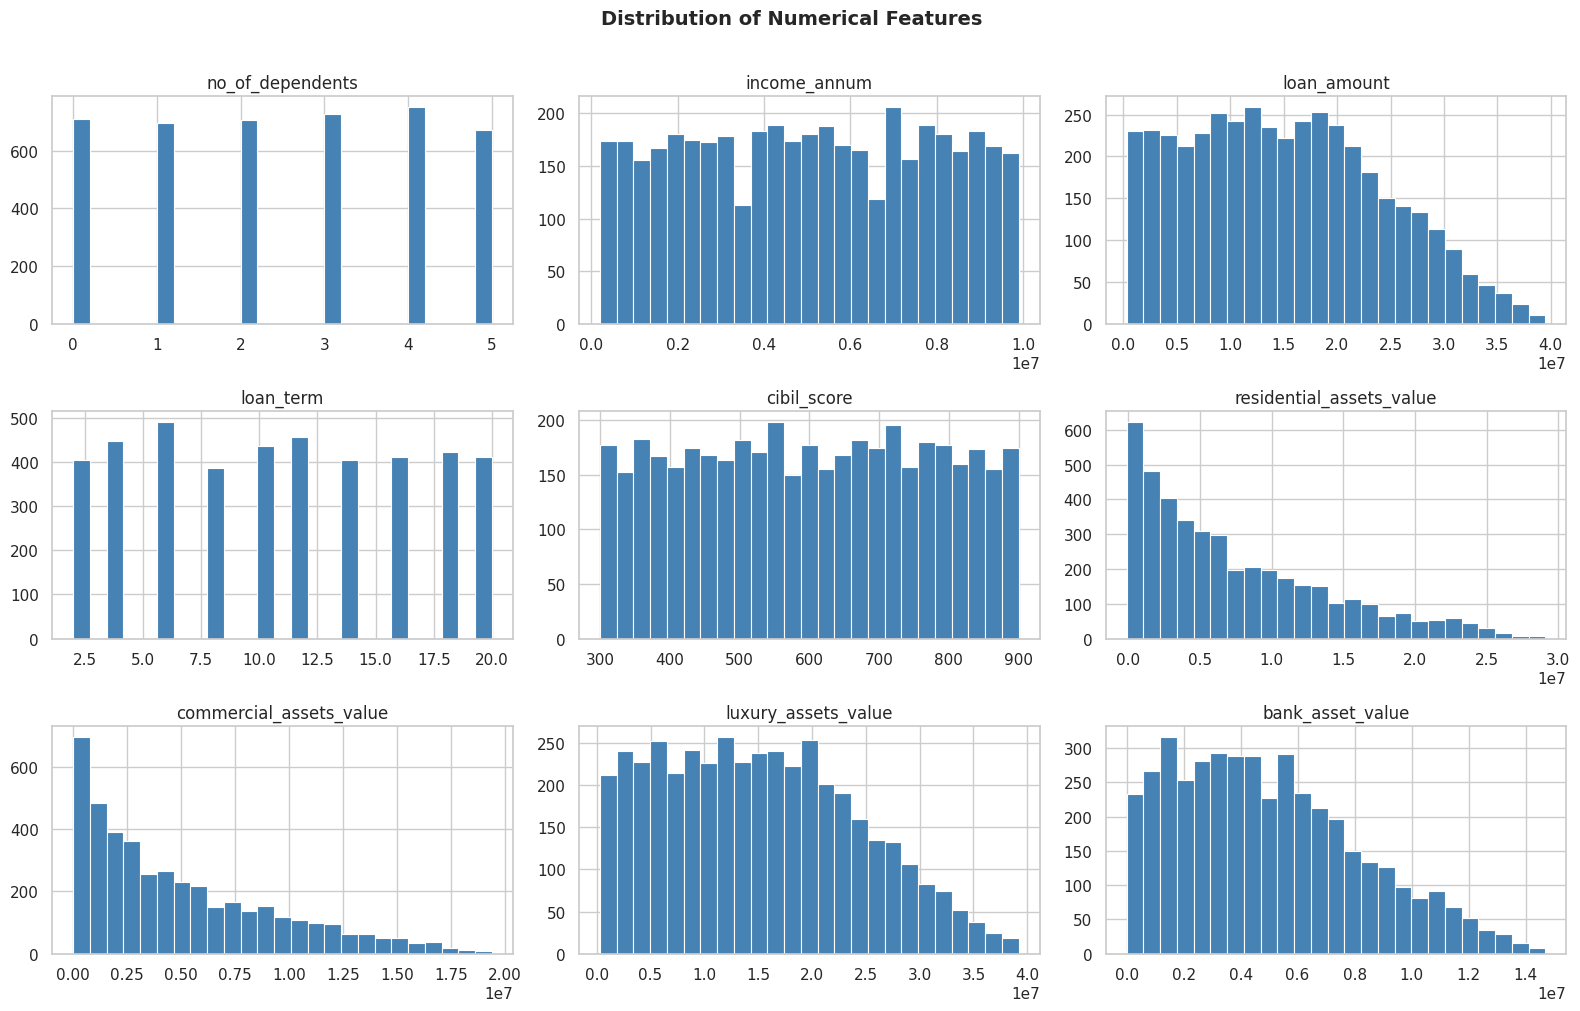

In [89]:
# 4.3 Numerical Feature Histograms
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(16, 10), bins=25, color='steelblue',
                  edgecolor='white', linewidth=0.8)
plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_03_numerical_histograms.png', dpi=300, bbox_inches='tight', facecolor='white', format='png')
plt.show()

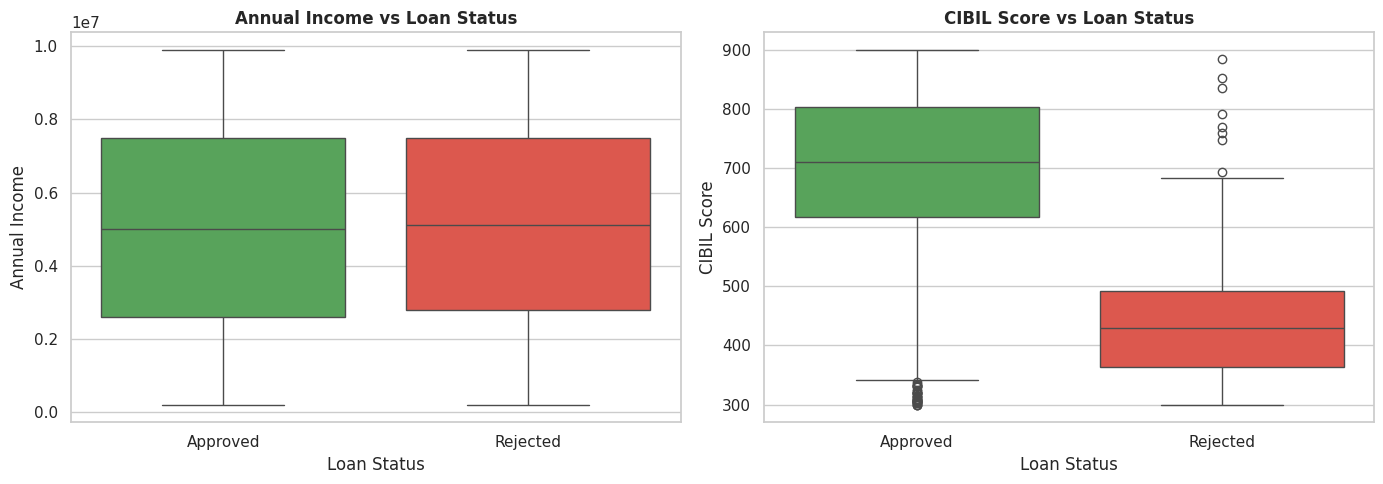

In [90]:
# 4.4 Box Plots: Income & CIBIL Score vs Loan Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='loan_status', y='income_annum', ax=axes[0],
            palette={'Approved': '#4CAF50', 'Rejected': '#F44336'})
axes[0].set_title('Annual Income vs Loan Status', fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Annual Income')

sns.boxplot(data=df, x='loan_status', y='cibil_score', ax=axes[1],
            palette={'Approved': '#4CAF50', 'Rejected': '#F44336'})
axes[1].set_title('CIBIL Score vs Loan Status', fontweight='bold')
axes[1].set_xlabel('Loan Status')
axes[1].set_ylabel('CIBIL Score')

plt.tight_layout()
plt.savefig('eda_04_boxplots.png', dpi=300, bbox_inches='tight', facecolor='white', format='png')
plt.show()

## Step 5: Data Preprocessing & Feature Encoding

In [91]:
# 5.1 Label Encoding
# education     : Graduate=0, Not Graduate=1 (ordinal — has inherent order)
# self_employed : No=0, Yes=1 (binary categorical)
# loan_status   : Approved=0, Rejected=1 (target variable)

le_edu    = LabelEncoder()
le_se     = LabelEncoder()
le_target = LabelEncoder()

df['education']    = le_edu.fit_transform(df['education'])
df['self_employed'] = le_se.fit_transform(df['self_employed'])
df['loan_status']  = le_target.fit_transform(df['loan_status'])

print("✅ Label Encoding complete.")
print(f"   education    classes : {list(le_edu.classes_)}")
print(f"   self_employed classes: {list(le_se.classes_)}")
print(f"   loan_status  classes : {list(le_target.classes_)}  → 0=Approved, 1=Rejected")

# Save encoders for Streamlit use
os.makedirs('models', exist_ok=True)
joblib.dump(le_edu,    'models/le_education.pkl')
joblib.dump(le_se,     'models/le_self_employed.pkl')
joblib.dump(le_target, 'models/le_target.pkl')
print("\n✅ Label Encoders saved to models/ folder.")

✅ Label Encoding complete.
   education    classes : ['Graduate', 'Not Graduate']
   self_employed classes: ['No', 'Yes']
   loan_status  classes : ['Approved', 'Rejected']  → 0=Approved, 1=Rejected

✅ Label Encoders saved to models/ folder.


In [92]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


## Step 6: Correlation Analysis

In [93]:
# 6.1 Correlation with Target
corr_with_target = df.corr()['loan_status'].sort_values(ascending=False)
print("📊 Correlation with loan_status:")
print(corr_with_target.to_string())

📊 Correlation with loan_status:
loan_status                 1.000000
loan_term                   0.113036
no_of_dependents            0.018114
luxury_assets_value         0.015465
income_annum                0.015189
residential_assets_value    0.014367
bank_asset_value            0.006778
education                   0.004918
self_employed              -0.000345
commercial_assets_value    -0.008246
loan_amount                -0.016150
cibil_score                -0.770518


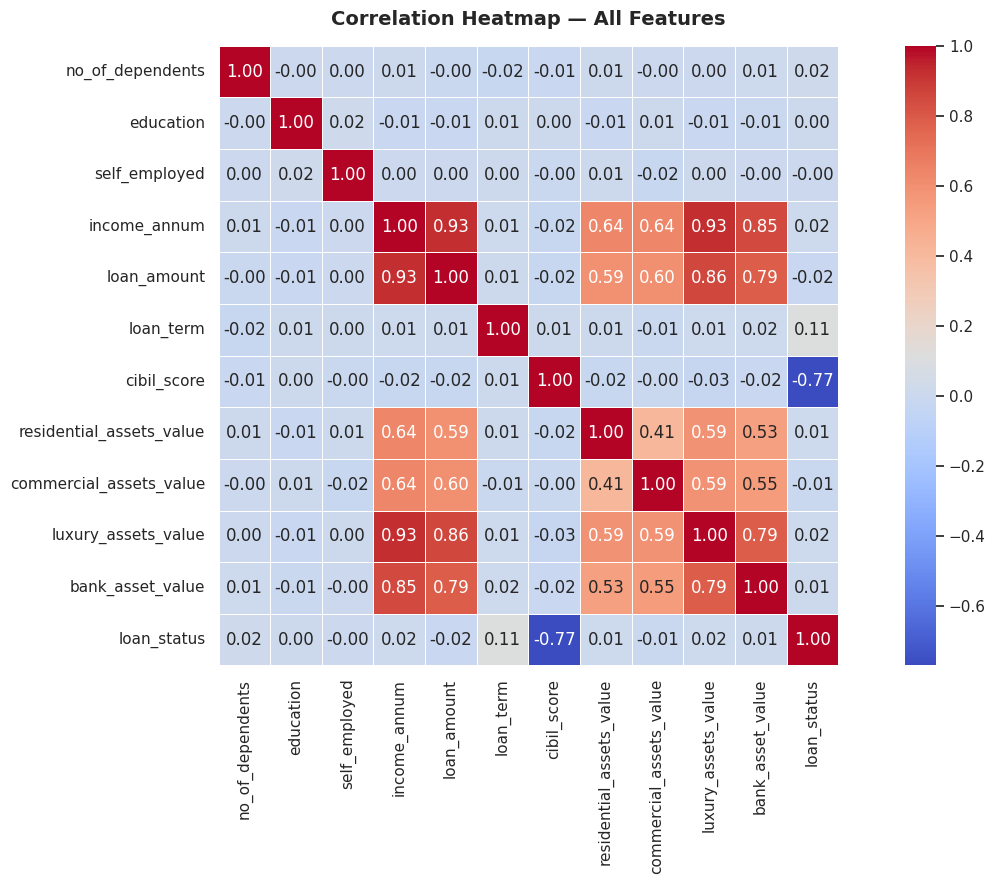

In [94]:
# 6.2 Correlation Heatmap
plt.figure(figsize=(14, 9))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap — All Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_05_correlation_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white', format='png')
plt.show()

## Step 7: Train-Test Split & Feature Scaling

In [95]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

print(f"Features (X) shape : {X.shape}")
print(f"Target  (y) shape  : {y.shape}")
print(f"Feature columns    : {list(X.columns)}")

Features (X) shape : (4269, 11)
Target  (y) shape  : (4269,)
Feature columns    : ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set : {X_train.shape[0]} samples")
print(f"Test  set : {X_test.shape[0]} samples")
print(f"\nClass distribution in train: {dict(pd.Series(y_train).value_counts())}")
print(f"Class distribution in test : {dict(pd.Series(y_test).value_counts())}")

Train set : 3415 samples
Test  set : 854 samples

Class distribution in train: {0: np.int64(2125), 1: np.int64(1290)}
Class distribution in test : {0: np.int64(531), 1: np.int64(323)}


In [97]:
# Standard Scaling (needed for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler for Streamlit
joblib.dump(scaler, 'models/scaler.pkl')
print("✅ StandardScaler fitted and saved to models/scaler.pkl")

✅ StandardScaler fitted and saved to models/scaler.pkl


## Step 8: Model 1 — Logistic Regression

In [98]:
# Train
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr   = lr_model.predict(X_test_scaled)
y_proba_lr  = lr_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Logistic Regression model trained.")

✅ Logistic Regression model trained.


In [99]:
# Performance Metrics
lr_acc  = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec  = recall_score(y_test, y_pred_lr)
lr_f1   = f1_score(y_test, y_pred_lr)
lr_roc  = roc_auc_score(y_test, y_proba_lr)
lr_cm   = confusion_matrix(y_test, y_pred_lr)

print("═" * 50)
print("       LOGISTIC REGRESSION — METRICS")
print("═" * 50)
print(f"  Accuracy       : {lr_acc  * 100:.4f} %")
print(f"  Precision      : {lr_prec * 100:.4f} %")
print(f"  Recall         : {lr_rec  * 100:.4f} %")
print(f"  F1 Score       : {lr_f1   * 100:.4f} %")
print(f"  ROC-AUC Score  : {lr_roc  * 100:.4f} %")
print("═" * 50)
print("\nConfusion Matrix:")
print(lr_cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_))

══════════════════════════════════════════════════
       LOGISTIC REGRESSION — METRICS
══════════════════════════════════════════════════
  Accuracy       : 92.2717 %
  Precision      : 91.5858 %
  Recall         : 87.6161 %
  F1 Score       : 89.5570 %
  ROC-AUC Score  : 97.4509 %
══════════════════════════════════════════════════

Confusion Matrix:
[[505  26]
 [ 40 283]]

Classification Report:
              precision    recall  f1-score   support

    Approved       0.93      0.95      0.94       531
    Rejected       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854



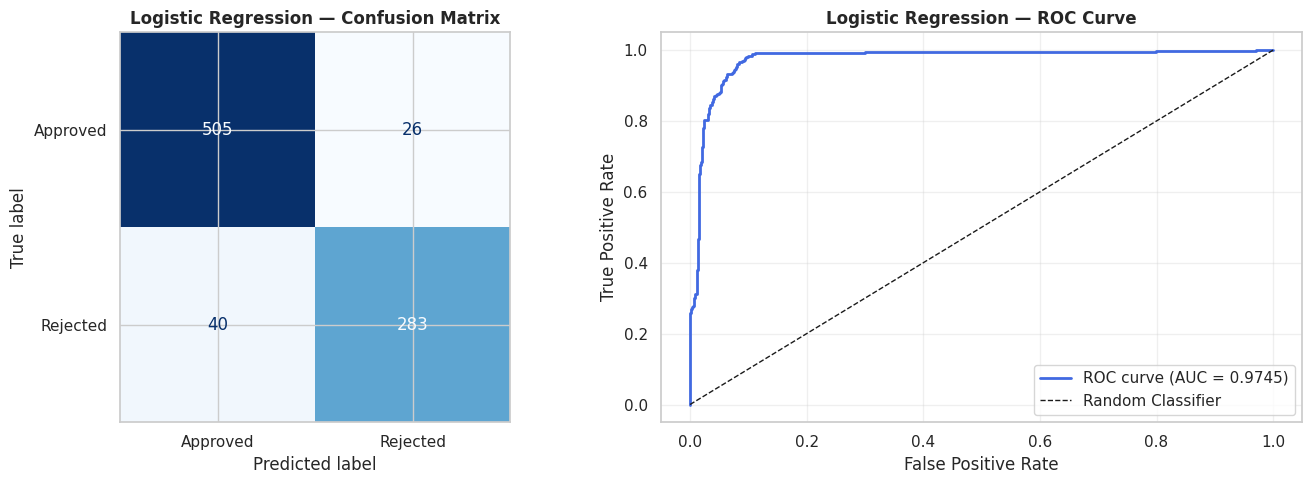

In [100]:
# Confusion Matrix Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=lr_cm, display_labels=le_target.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression — Confusion Matrix', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
axes[1].plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC curve (AUC = {lr_roc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Logistic Regression — ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_06_lr_confusion_roc.png', dpi=300, bbox_inches='tight', facecolor='white', format='png')
plt.show()

## Step 9: Model 2 — Random Forest Classifier

In [101]:
# Train
# Note: Random Forest does NOT require feature scaling
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)   # uses unscaled data

y_pred_rf  = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("✅ Random Forest model trained.")

✅ Random Forest model trained.


In [102]:
# Performance Metrics
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec  = recall_score(y_test, y_pred_rf)
rf_f1   = f1_score(y_test, y_pred_rf)
rf_roc  = roc_auc_score(y_test, y_proba_rf)
rf_cm   = confusion_matrix(y_test, y_pred_rf)

print("═" * 50)
print("       RANDOM FOREST — METRICS")
print("═" * 50)
print(f"  Accuracy       : {rf_acc  * 100:.4f} %")
print(f"  Precision      : {rf_prec * 100:.4f} %")
print(f"  Recall         : {rf_rec  * 100:.4f} %")
print(f"  F1 Score       : {rf_f1   * 100:.4f} %")
print(f"  ROC-AUC Score  : {rf_roc  * 100:.4f} %")
print("═" * 50)
print("\nConfusion Matrix:")
print(rf_cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

══════════════════════════════════════════════════
       RANDOM FOREST — METRICS
══════════════════════════════════════════════════
  Accuracy       : 98.3607 %
  Precision      : 99.0476 %
  Recall         : 96.5944 %
  F1 Score       : 97.8056 %
  ROC-AUC Score  : 99.7956 %
══════════════════════════════════════════════════

Confusion Matrix:
[[528   3]
 [ 11 312]]

Classification Report:
              precision    recall  f1-score   support

    Approved       0.98      0.99      0.99       531
    Rejected       0.99      0.97      0.98       323

    accuracy                           0.98       854
   macro avg       0.99      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



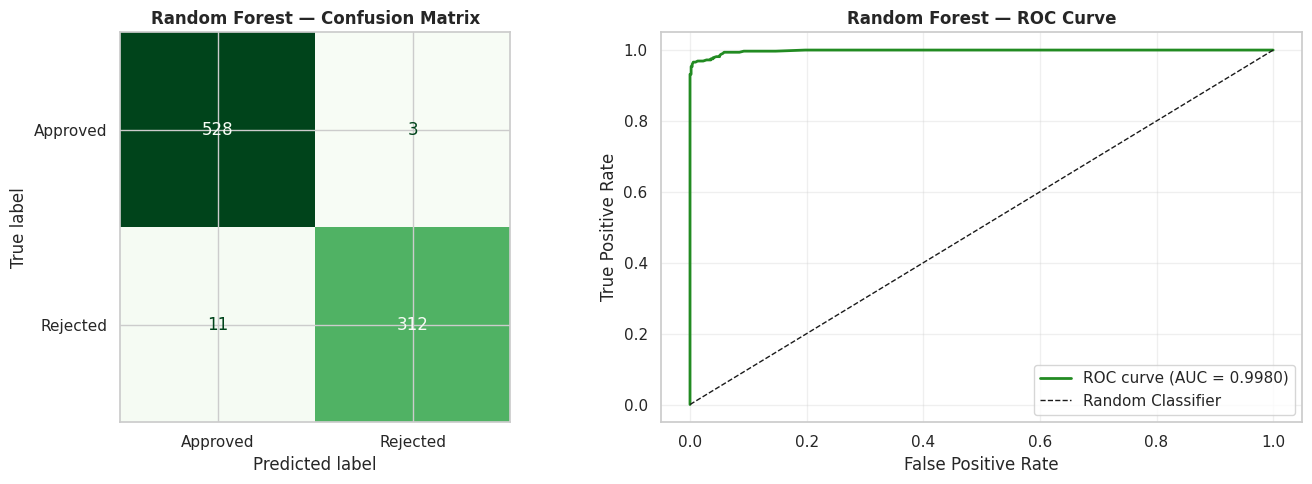

In [103]:
# Confusion Matrix & ROC Curve Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp2 = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=le_target.classes_)
disp2.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Random Forest — Confusion Matrix', fontweight='bold')

fpr2, tpr2, _ = roc_curve(y_test, y_proba_rf)
axes[1].plot(fpr2, tpr2, color='forestgreen', lw=2, label=f'ROC curve (AUC = {rf_roc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Random Forest — ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_07_rf_confusion_roc.png', dpi=300, bbox_inches='tight', facecolor='white', format='png')
plt.show()

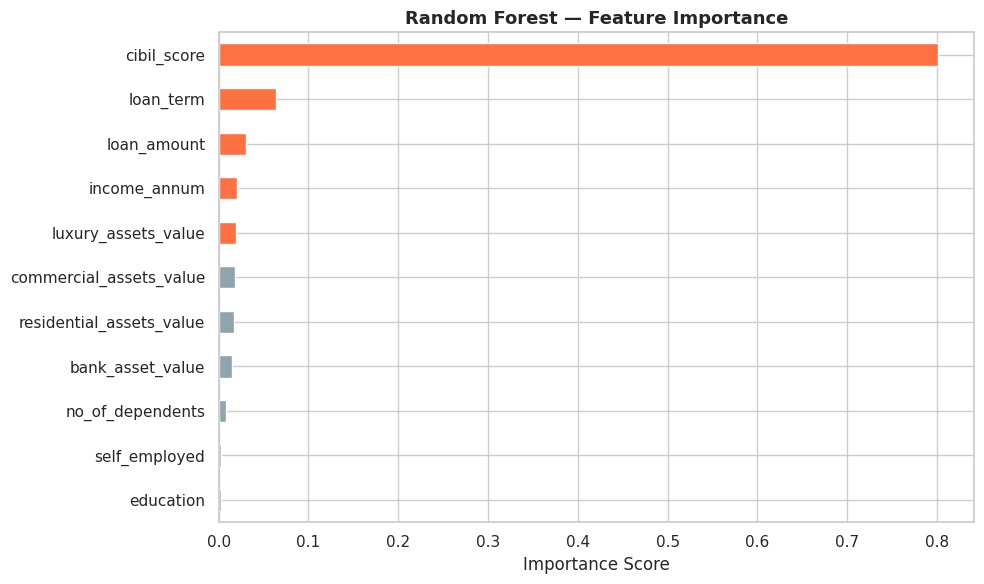


Feature Importances (sorted):
cibil_score                 0.801152
loan_term                   0.064358
loan_amount                 0.030672
income_annum                0.020317
luxury_assets_value         0.019399
commercial_assets_value     0.018403
residential_assets_value    0.017593
bank_asset_value            0.015068
no_of_dependents            0.007783
self_employed               0.002866
education                   0.002389


<Figure size 640x480 with 0 Axes>

In [104]:
# Feature Importance (Random Forest)
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#FF7043' if v > feat_imp.median() else '#90A4AE' for v in feat_imp.values]
feat_imp.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature Importances (sorted):")
plt.savefig('eda_08_feature_importance.png', dpi=300, bbox_inches='tight', facecolor='white', format='png')
print(feat_imp.sort_values(ascending=False).to_string())

## Step 10: Model Comparison

In [105]:
# Side-by-Side Comparison Table
comparison = pd.DataFrame({
    'Metric'     : ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Logistic Regression': [
        f"{lr_acc*100:.4f}%", f"{lr_prec*100:.4f}%",
        f"{lr_rec*100:.4f}%",  f"{lr_f1*100:.4f}%", f"{lr_roc*100:.4f}%"
    ],
    'Random Forest': [
        f"{rf_acc*100:.4f}%", f"{rf_prec*100:.4f}%",
        f"{rf_rec*100:.4f}%",  f"{rf_f1*100:.4f}%", f"{rf_roc*100:.4f}%"
    ]
})

comparison.set_index('Metric', inplace=True)
print("\n" + "═"*55)
print("          MODEL COMPARISON TABLE")
print("═"*55)
print(comparison.to_string())
print("═"*55)


═══════════════════════════════════════════════════════
          MODEL COMPARISON TABLE
═══════════════════════════════════════════════════════
          Logistic Regression Random Forest
Metric                                     
Accuracy             92.2717%      98.3607%
Precision            91.5858%      99.0476%
Recall               87.6161%      96.5944%
F1 Score             89.5570%      97.8056%
ROC-AUC              97.4509%      99.7956%
═══════════════════════════════════════════════════════


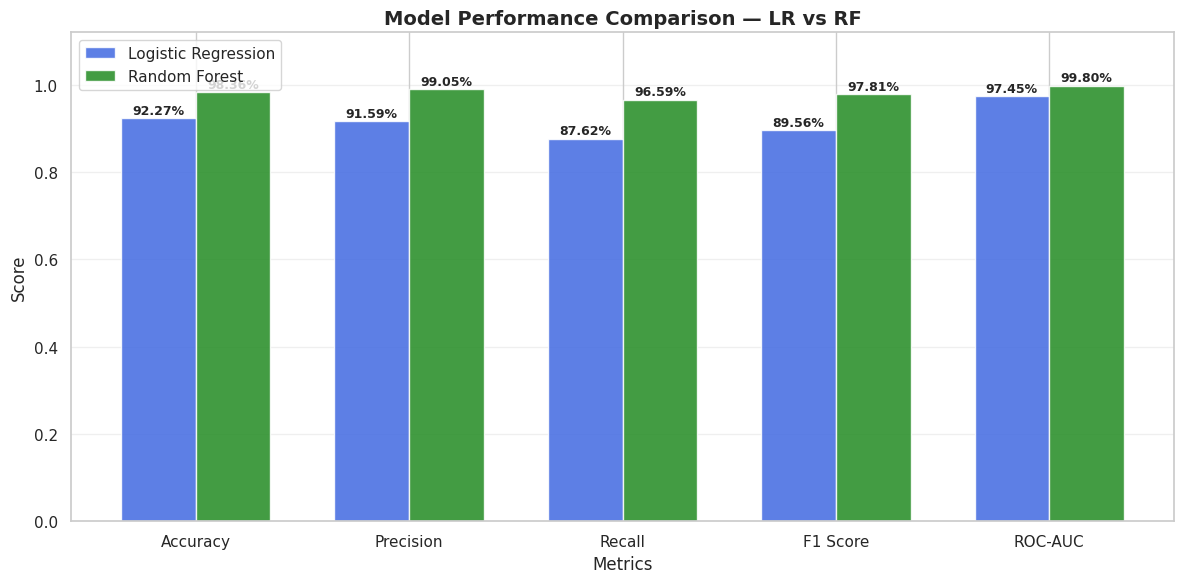

In [106]:
# Visual Comparison Bar Chart
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
lr_scores   = [lr_acc, lr_prec, lr_rec, lr_f1, lr_roc]
rf_scores   = [rf_acc, rf_prec, rf_rec, rf_f1, rf_roc]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression',
               color='royalblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest',
               color='forestgreen', alpha=0.85, edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height()*100:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height()*100:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — LR vs RF', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_09_model_comparison.png', dpi=300, bbox_inches='tight', facecolor='white', format='png')
plt.show()

## Step 11: Save Models & Artifacts as .pkl Files

In [107]:
os.makedirs('models', exist_ok=True)

# Save Logistic Regression model
joblib.dump(lr_model, 'models/logistic_regression.pkl')
print("✅ Saved: models/logistic_regression.pkl")

# Save Random Forest model
joblib.dump(rf_model, 'models/random_forest.pkl')
print("✅ Saved: models/random_forest.pkl")

# Save StandardScaler (used only by Logistic Regression)
joblib.dump(scaler, 'models/scaler.pkl')
print("✅ Saved: models/scaler.pkl")

# Save Label Encoders
joblib.dump(le_edu,    'models/le_education.pkl')
joblib.dump(le_se,     'models/le_self_employed.pkl')
joblib.dump(le_target, 'models/le_target.pkl')
print("✅ Saved: models/le_education.pkl")
print("✅ Saved: models/le_self_employed.pkl")
print("✅ Saved: models/le_target.pkl")

# Save model accuracy scores for Streamlit display
import json
model_metrics = {
    'Logistic Regression': {
        'accuracy' : round(lr_acc  * 100, 4),
        'precision': round(lr_prec * 100, 4),
        'recall'   : round(lr_rec  * 100, 4),
        'f1_score' : round(lr_f1   * 100, 4),
        'roc_auc'  : round(lr_roc  * 100, 4)
    },
    'Random Forest': {
        'accuracy' : round(rf_acc  * 100, 4),
        'precision': round(rf_prec * 100, 4),
        'recall'   : round(rf_rec  * 100, 4),
        'f1_score' : round(rf_f1   * 100, 4),
        'roc_auc'  : round(rf_roc  * 100, 4)
    }
}
with open('models/model_metrics.json', 'w') as f:
    json.dump(model_metrics, f, indent=2)
print("✅ Saved: models/model_metrics.json")

print("\n📦 All artifacts saved in 'models/' folder successfully!")
print("\n📁 Saved files:")
for fname in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{fname}')
    print(f"   {fname:40s} {size:>10,} bytes")

✅ Saved: models/logistic_regression.pkl
✅ Saved: models/random_forest.pkl
✅ Saved: models/scaler.pkl
✅ Saved: models/le_education.pkl
✅ Saved: models/le_self_employed.pkl
✅ Saved: models/le_target.pkl
✅ Saved: models/model_metrics.json

📦 All artifacts saved in 'models/' folder successfully!

📁 Saved files:
   le_education.pkl                                499 bytes
   le_self_employed.pkl                            484 bytes
   le_target.pkl                                   495 bytes
   logistic_regression.pkl                         959 bytes
   model_metrics.json                              303 bytes
   random_forest.pkl                         1,832,793 bytes
   scaler.pkl                                    1,311 bytes


---
## ✅ Summary

| Step | Task |
|------|------|
| 1 | Imported all libraries |
| 2 | Loaded dataset (4269 rows × 13 columns) |
| 3 | Data cleaning: null check, duplicate check, whitespace stripping, dropped `loan_id` |
| 4 | EDA: class distribution, categorical/numerical plots, boxplots |
| 5 | Feature encoding: LabelEncoder for all categorical columns |
| 6 | Correlation analysis and heatmap |
| 7 | Train-Test split (80/20, stratified) + StandardScaler |
| 8 | Logistic Regression — trained + full metrics |
| 9 | Random Forest — trained + full metrics + feature importance |
| 10 | Side-by-side model comparison |
| 11 | Saved all models and artifacts as `.pkl` / `.json` files |

**Best performing model → Random Forest Classifier (~97.7% accuracy)**